Import Libraries

In [366]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from itertools import chain, combinations

import joblib

Set Dataset Path

In [367]:
DATA_PATH = "../datasets/patuakhali_soil_element (Ec,PH,NPKS).xlsm - English Data (1).csv"

Load Dataset

In [368]:
df = pd.read_csv(DATA_PATH)
df.head()

,Soil Sample Serial No.,District,Land Class,Soil Texture,Reaction (pH),"Salinity (EC, dS/m)",Organic Matter (%),Total Nitrogen (%),Available Phosphorus (B)* (µg/g soil),Available Phosphorus (O)** (µg/g soil),Potassium (meq/100 g soil),Sulfur (µg/g soil),Zinc (µg/g soil),Boron (meq/100 g soil),Calcium (meq/100 g soil),Magnesium (µg/g soil),Copper (µg/g soil),Manganese (µg/g soil)
0,4,Ramgati,Medium high land,Loam,8.0,1.63,0.95,0.06,18.19,NaN,0.07,20.30,0.09,0.35,7.06,1.83,0.70,1.08
1,5,Rangamati,Medium high land,Loam,6.5,1.25,1.31,0.08,0.00,2.64,0.07,12.01,0.14,0.32,4.22,2.65,1.34,1.57
2,27,Rangamati,Medium high land,Loam,6.8,5.59,1.34,0.08,4.78,NaN,0.07,94.54,0.16,0.32,6.58,2.28,0.89,1.12
3,29,Rangamati,Medium high land,Loam,5.4,1.67,1.94,0.11,NaN,4.13,0.09,16.80,0.16,0.35,2.50,2.10,1.72,2.01
4,44,Rangamati,Medium high land,Loam,6.3,0.99,1.35,0.08,NaN,2.19,0.08,20.32,0.15,0.39,4.00,2.61,1.29,2.45


In [369]:
df["Organic Matter (%)"] = pd.to_numeric(df["Organic Matter (%)"], errors='coerce')

In [370]:
po = "Available Phosphorus (B)* (µg/g soil)"
pb = "Available Phosphorus (O)** (µg/g soil)"

filter = df[po].notna() & df[pb].notna()
df.loc[filter, [po, pb]]

,Available Phosphorus (B)* (µg/g soil),Available Phosphorus (O)** (µg/g soil)
1,0.0,2.64


In [371]:
merged_p = "Available Phosphorus (µg/g soil)"

if po in df.columns and pb in df.columns:
    df[merged_p] = df[po].combine_first(df[pb])
    df = df.drop(columns=[po, pb])

df.columns
    

Index(['Soil Sample Serial No.', 'District', 'Land Class', 'Soil Texture',
       'Reaction (pH)', 'Salinity (EC, dS/m)', 'Organic Matter (%)',
       'Total Nitrogen (%)', 'Potassium (meq/100 g soil)',
       'Sulfur (µg/g soil)', 'Zinc (µg/g soil)', 'Boron (meq/100 g soil)',
       'Calcium (meq/100 g soil)', 'Magnesium (µg/g soil)',
       'Copper  (µg/g soil)', 'Manganese (µg/g soil)',
       'Available Phosphorus (µg/g soil)'],
      dtype='object')

In [372]:
TARGET = 'Available Phosphorus (µg/g soil)'
df[TARGET].describe()

count    94.000000
mean      4.137766
std       3.316060
min       0.000000
25%       2.380000
50%       2.930000
75%       4.152500
max      18.190000
Name: Available Phosphorus (µg/g soil), dtype: float64

In [373]:
numeric_columns = [
    "Reaction (pH)",
    "Salinity (EC, dS/m)",
    "Organic Matter (%)",
    "Total Nitrogen (%)",
    "Potassium (meq/100 g soil)",
    "Sulfur (µg/g soil)",
    'Calcium (meq/100 g soil)', 
    'Magnesium (µg/g soil)',
]

categorical_columns = [
    "District",
    "Land Class",
    "Soil Texture",
]

In [374]:
numeric_columns = [col for col in numeric_columns if col in df.columns]
categorical_columns = [col for col in categorical_columns if col in df.columns]

print(f"Numeric columns used: {len(numeric_columns)}")
print(numeric_columns)

print(f"\nCategorical columns used: {len(categorical_columns)}")
print(categorical_columns)

Numeric columns used: 8
['Reaction (pH)', 'Salinity (EC, dS/m)', 'Organic Matter (%)', 'Total Nitrogen (%)', 'Potassium (meq/100 g soil)', 'Sulfur (µg/g soil)', 'Calcium (meq/100 g soil)', 'Magnesium (µg/g soil)']

Categorical columns used: 3
['District', 'Land Class', 'Soil Texture']


In [375]:
for col in numeric_columns + [TARGET]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

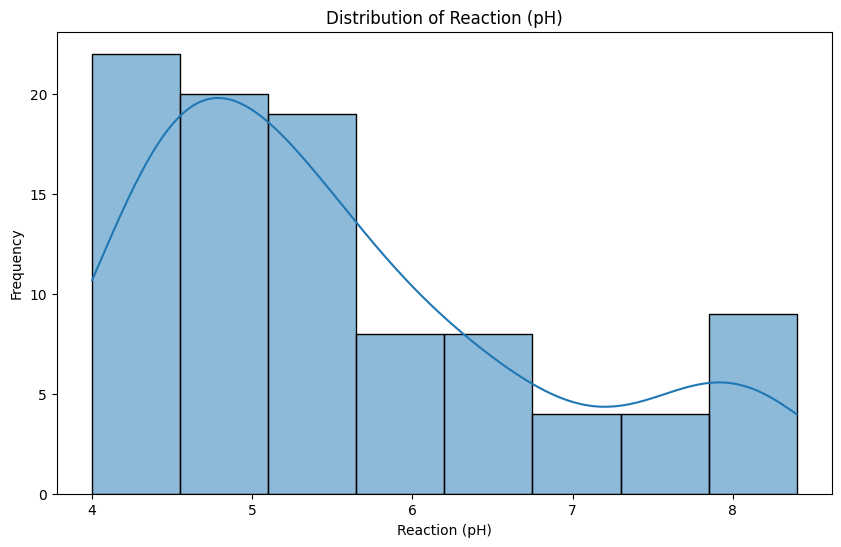

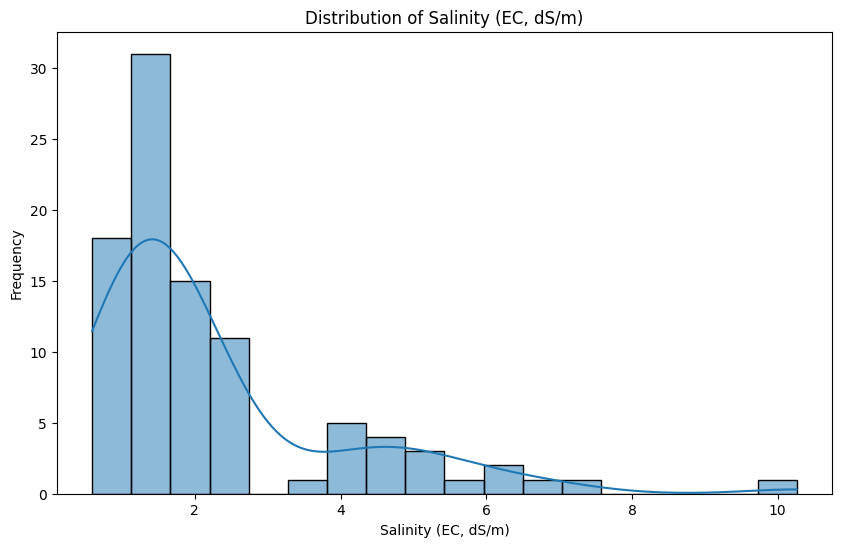

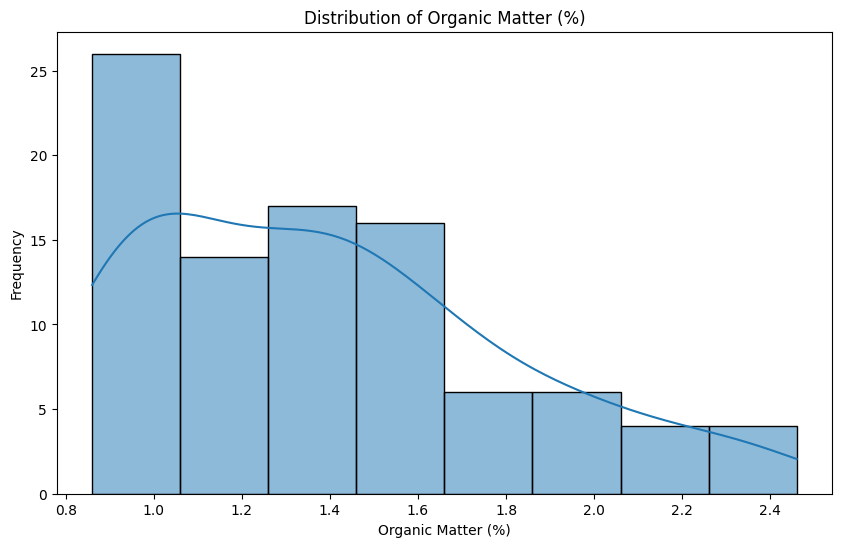

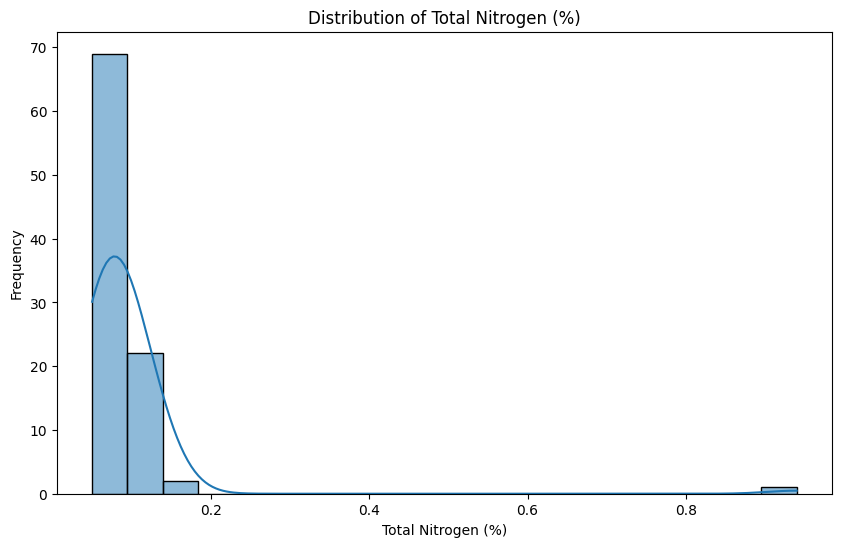

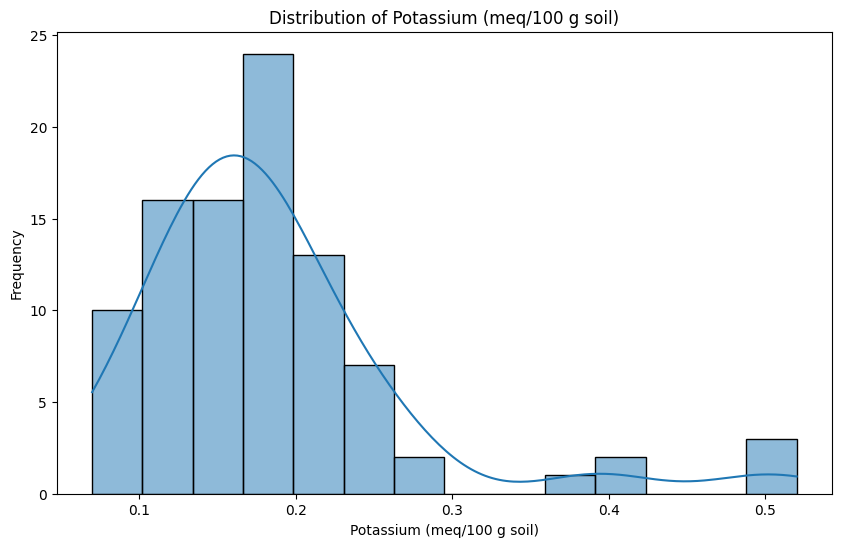

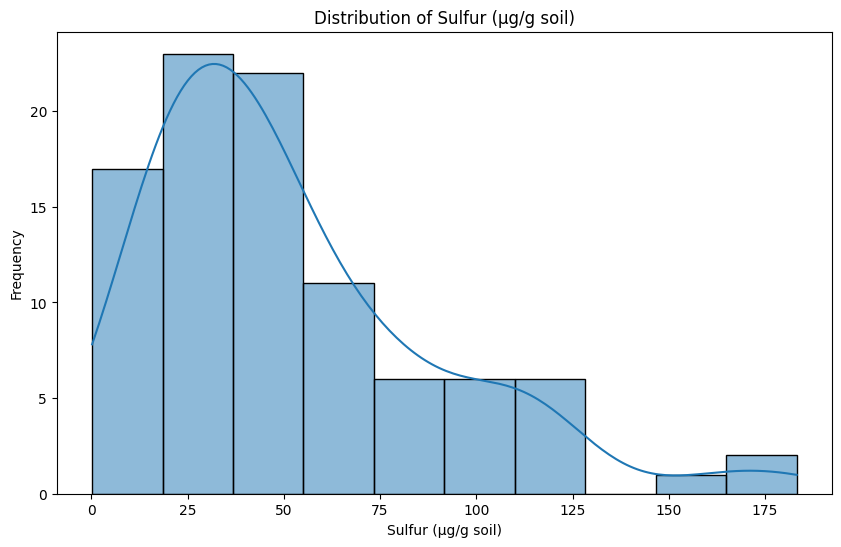

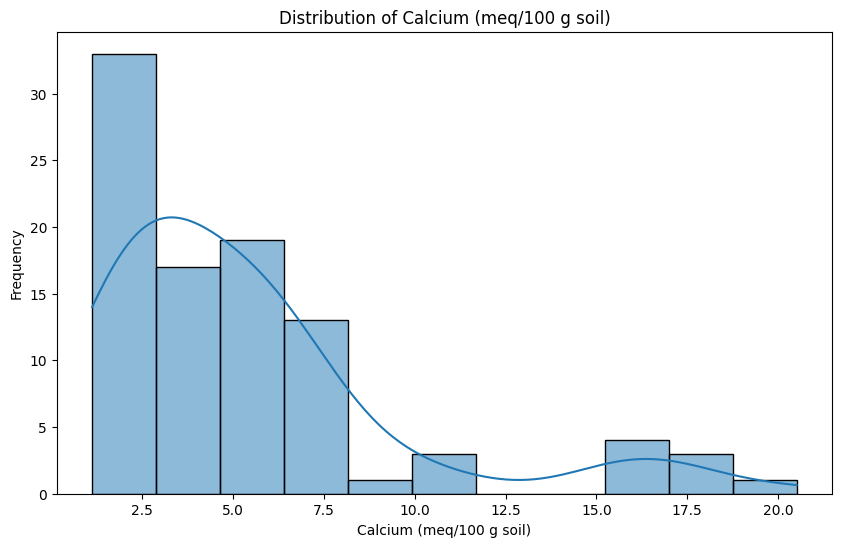

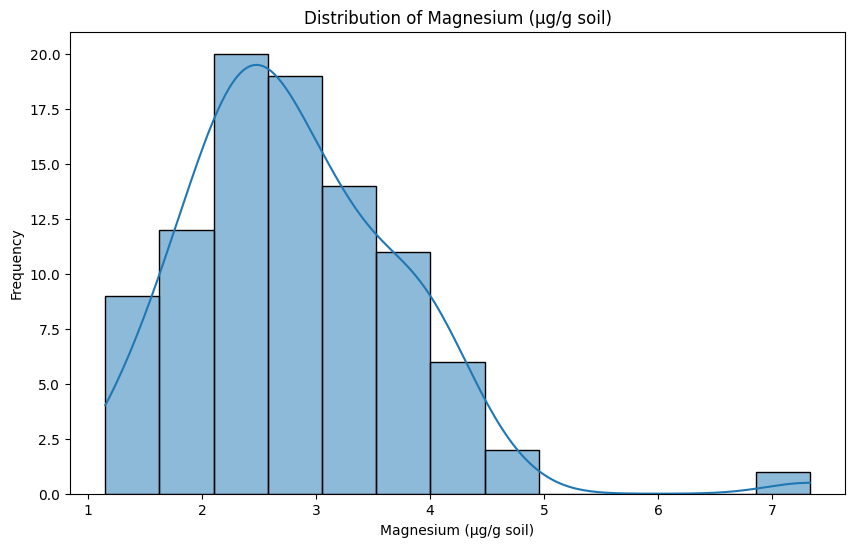

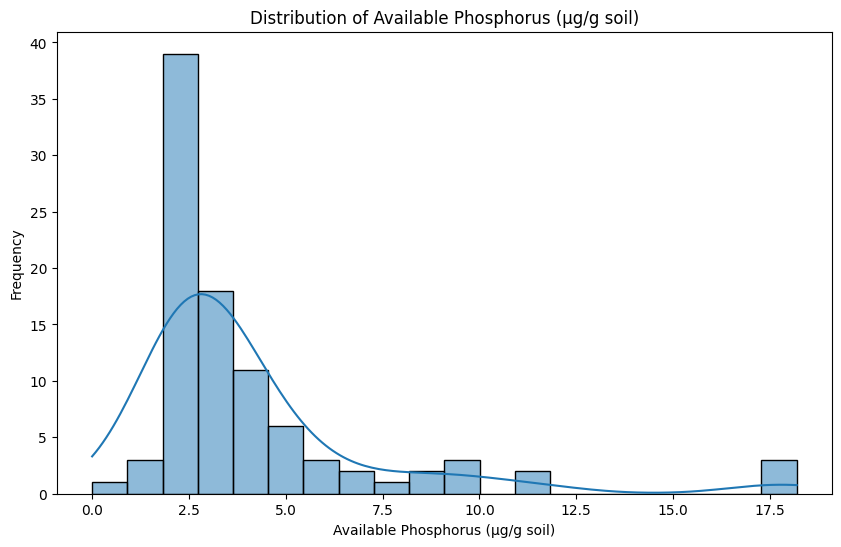

In [376]:
for col in numeric_columns + [TARGET]:
    plt.figure(figsize=(10,6))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [377]:

df[TARGET].describe()

count    94.000000
mean      4.137766
std       3.316060
min       0.000000
25%       2.380000
50%       2.930000
75%       4.152500
max      18.190000
Name: Available Phosphorus (µg/g soil), dtype: float64

In [378]:


Q1 = df[TARGET].quantile(0.25)
Q3 = df[TARGET].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[TARGET] < lower_bound) | (df[TARGET] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Total outliers:", len(outliers))

(df[TARGET]>15).sum()

Lower bound: -0.27875000000000005
Upper bound: 6.811249999999999
Total outliers: 13


np.int64(3)

In [379]:
df = df[df[TARGET] <= 15]

<Axes: >

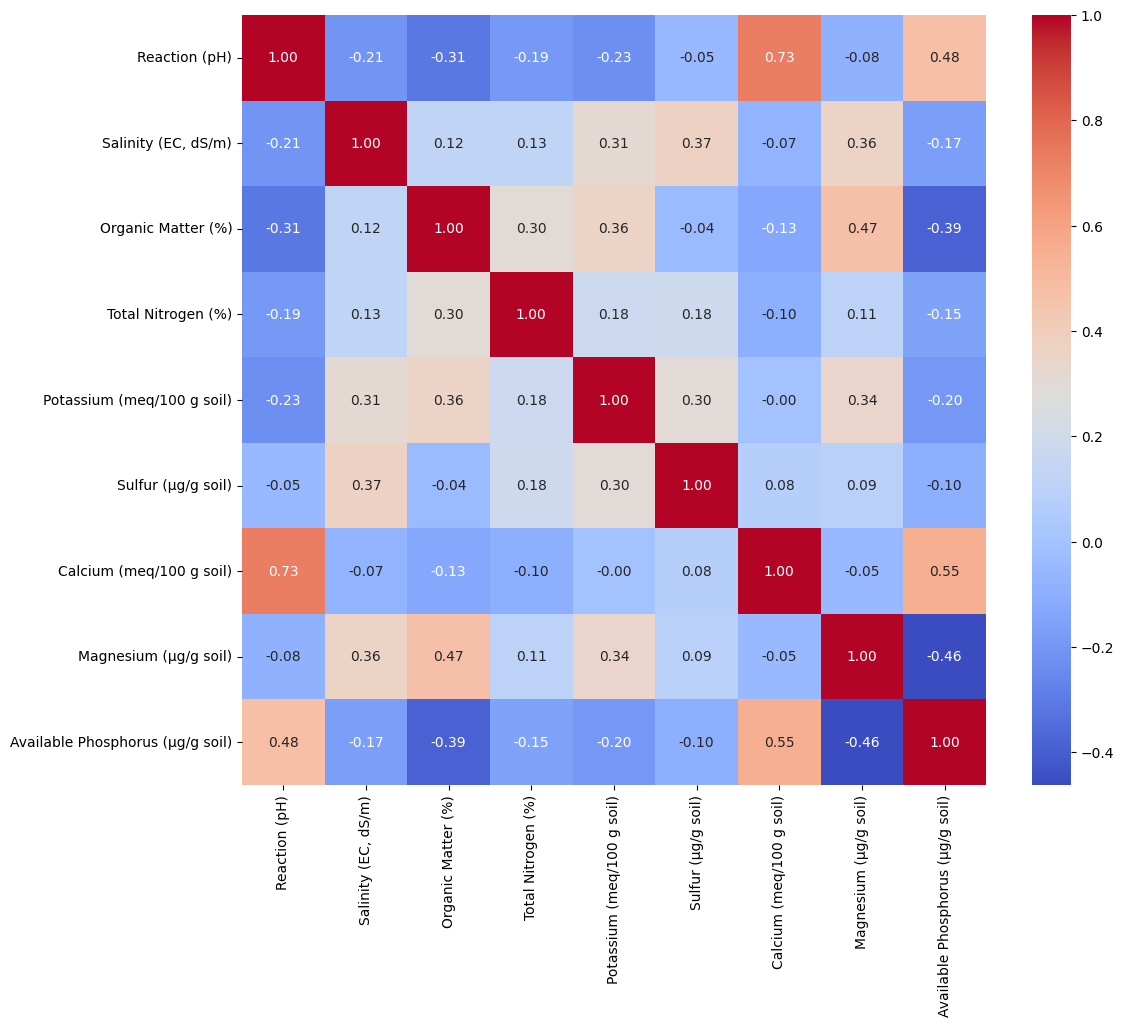

In [380]:
corr_cols = numeric_columns + [TARGET]
corr_df = df[corr_cols].copy()
plt.figure(figsize=(12,10))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [381]:
df[numeric_columns + [TARGET]].describe()

,Reaction (pH),"Salinity (EC, dS/m)",Organic Matter (%),Total Nitrogen (%),Potassium (meq/100 g soil),Sulfur (µg/g soil),Calcium (meq/100 g soil),Magnesium (µg/g soil),Available Phosphorus (µg/g soil)
count,91.000000,91.000000,90.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000
mean,5.459341,2.296593,1.408333,0.091901,0.186374,53.114176,5.050110,2.836374,3.687582
std,1.151615,1.763225,0.413511,0.093046,0.086198,37.693261,3.776646,0.939957,2.222479
min,4.000000,0.590000,0.860000,0.050000,0.070000,0.230000,1.120000,1.150000,0.000000
25%,4.600000,1.215000,1.050000,0.060000,0.130000,26.735000,2.385000,2.205000,2.365000
50%,5.200000,1.640000,1.365000,0.080000,0.170000,43.190000,4.100000,2.650000,2.850000
75%,6.050000,2.465000,1.645000,0.100000,0.210000,70.335000,6.215000,3.360000,4.050000
max,8.400000,10.260000,2.460000,0.940000,0.520000,183.200000,17.480000,7.330000,11.510000


In [382]:
filtered_df = df[
    (df["District"] == "Jhalokathi") &
    (df["Land Class"] == "Medium high land") &
    (df["Soil Texture"] == "Clay loam") &
    (df["Reaction (pH)"] > 5) &
    (df["Reaction (pH)"] < 6) &
    (df["Salinity (EC, dS/m)"] == 1.95)
]

filtered_df

,Soil Sample Serial No.,District,Land Class,Soil Texture,Reaction (pH),"Salinity (EC, dS/m)",Organic Matter (%),Total Nitrogen (%),Potassium (meq/100 g soil),Sulfur (µg/g soil),Zinc (µg/g soil),Boron (meq/100 g soil),Calcium (meq/100 g soil),Magnesium (µg/g soil),Copper (µg/g soil),Manganese (µg/g soil),Available Phosphorus (µg/g soil)
15,78,Jhalokathi,Medium high land,Clay loam,5.4,1.95,2.29,0.13,0.20,43.19,0.28,0.28,5.93,3.74,3.57,14.55,4.05
16,79,Jhalokathi,Medium high land,Clay loam,5.3,1.95,2.41,0.14,0.38,31.34,8.04,0.40,6.70,7.33,3.50,41.28,2.51


In [383]:
df.loc[df["Zinc (µg/g soil)"] == 8.04, "Zinc (µg/g soil)"] = 0.84

In [384]:
df.loc[df[TARGET] == 0.94, TARGET] = 0.094

In [385]:
df.describe()

,Soil Sample Serial No.,Reaction (pH),"Salinity (EC, dS/m)",Organic Matter (%),Total Nitrogen (%),Potassium (meq/100 g soil),Sulfur (µg/g soil),Zinc (µg/g soil),Boron (meq/100 g soil),Calcium (meq/100 g soil),Magnesium (µg/g soil),Copper (µg/g soil),Manganese (µg/g soil),Available Phosphorus (µg/g soil)
count,91.000000,91.000000,91.000000,90.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000
mean,46.483516,5.459341,2.296593,1.408333,0.091901,0.186374,53.114176,0.358352,0.387473,5.050110,2.836374,2.548352,7.886813,3.687582
std,26.363848,1.151615,1.763225,0.413511,0.093046,0.086198,37.693261,0.489218,0.141967,3.776646,0.939957,0.941038,9.554256,2.222479
min,1.000000,4.000000,0.590000,0.860000,0.050000,0.070000,0.230000,0.050000,0.100000,1.120000,1.150000,0.890000,0.640000,0.000000
25%,24.500000,4.600000,1.215000,1.050000,0.060000,0.130000,26.735000,0.100000,0.300000,2.385000,2.205000,1.810000,2.660000,2.365000
50%,46.000000,5.200000,1.640000,1.365000,0.080000,0.170000,43.190000,0.190000,0.370000,4.100000,2.650000,2.320000,5.040000,2.850000
75%,68.500000,6.050000,2.465000,1.645000,0.100000,0.210000,70.335000,0.370000,0.445000,6.215000,3.360000,3.510000,7.975000,4.050000
max,92.000000,8.400000,10.260000,2.460000,0.940000,0.520000,183.200000,2.880000,0.930000,17.480000,7.330000,4.600000,45.740000,11.510000


In [386]:
df[df["Available Phosphorus (µg/g soil)"] > 5]

,Soil Sample Serial No.,District,Land Class,Soil Texture,Reaction (pH),"Salinity (EC, dS/m)",Organic Matter (%),Total Nitrogen (%),Potassium (meq/100 g soil),Sulfur (µg/g soil),Zinc (µg/g soil),Boron (meq/100 g soil),Calcium (meq/100 g soil),Magnesium (µg/g soil),Copper (µg/g soil),Manganese (µg/g soil),Available Phosphorus (µg/g soil)
38,21,Jhalokathi,Medium high land,Clay loam,4.6,4.59,1.00,0.06,0.14,21.09,0.09,0.49,2.34,2.50,1.57,4.07,6.94
65,46,Jhalokathi,Medium high land,Clay loam,5.0,0.59,1.11,0.06,0.14,32.76,0.88,0.50,1.27,2.00,4.52,7.78,7.19
68,65,Jhalokathi,Medium high land,Loam,4.5,1.40,1.63,0.10,0.17,27.89,0.14,0.33,3.79,3.28,2.28,2.58,5.95
69,68,Jhalokathi,Medium high land,Clay loam,4.7,1.70,1.40,0.08,0.17,6.95,0.37,0.42,1.85,2.19,2.60,2.79,5.84
72,13,Barishal,Medium high land,Clay loam,4.2,2.23,1.22,0.07,0.17,113.60,0.77,0.33,1.86,2.78,3.72,5.82,5.47
76,70,Bhola,Medium high land,Clay loam,6.8,1.68,1.20,0.07,0.09,48.80,0.09,0.37,2.17,2.31,1.76,7.61,9.04
77,55,Nilkamal,Medium high land,Clay loam,7.6,1.71,0.91,0.05,0.16,48.67,0.06,0.36,7.24,1.93,1.52,3.20,5.19
85,32,Meghnar Paschimati,Medium high land,Loam,5.6,0.69,0.95,0.06,0.13,12.62,0.09,0.46,15.45,1.58,4.04,6.01,11.51
86,32,Meghnar Paschimati,Medium low land,Loam,8.2,0.69,0.95,0.06,0.13,12.62,0.09,0.46,15.45,1.58,4.04,6.01,11.51
88,83,Meghnar Paschimati,Medium low land,Loam,8.0,1.10,0.88,0.05,0.15,40.91,0.10,0.44,17.07,1.54,1.84,3.39,9.12


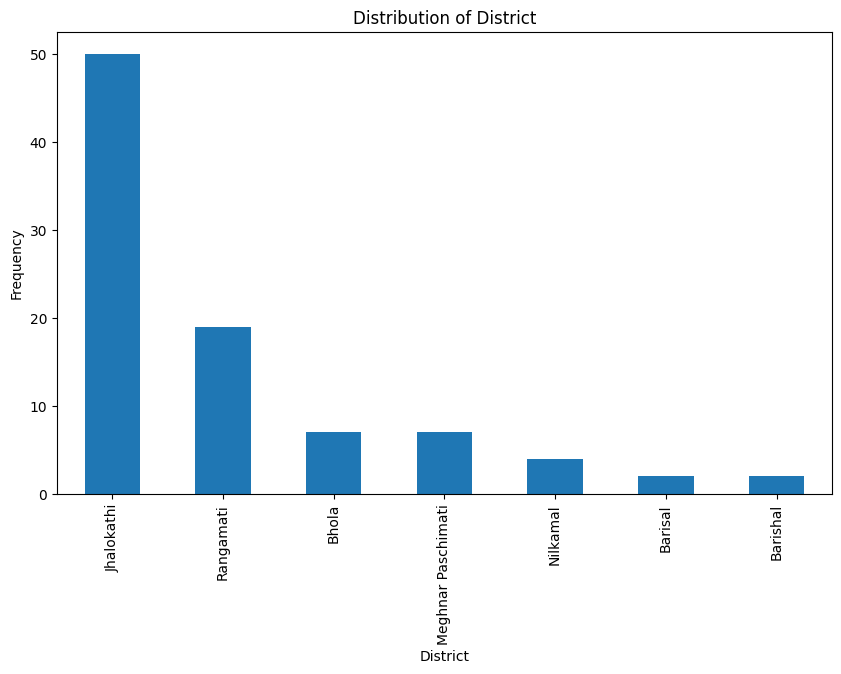

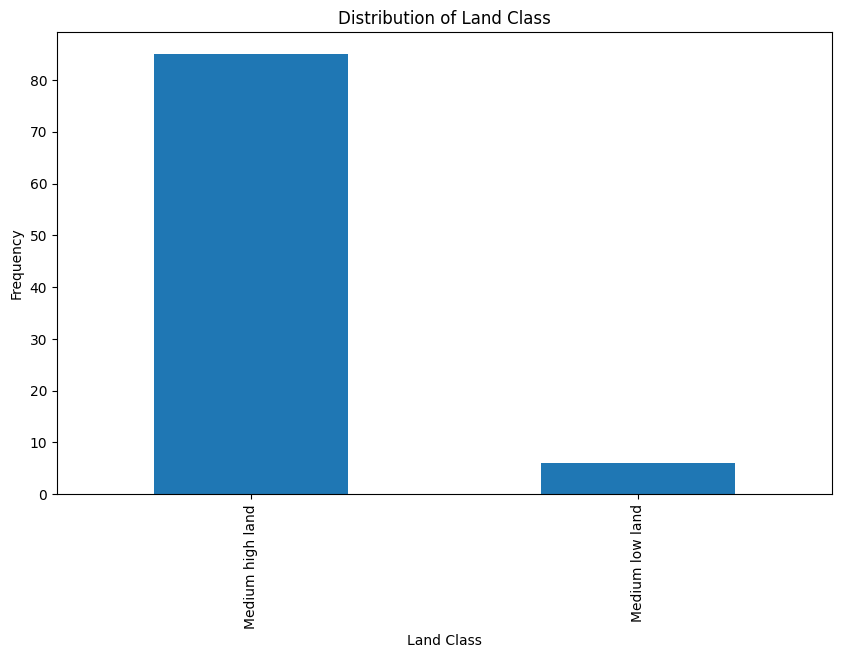

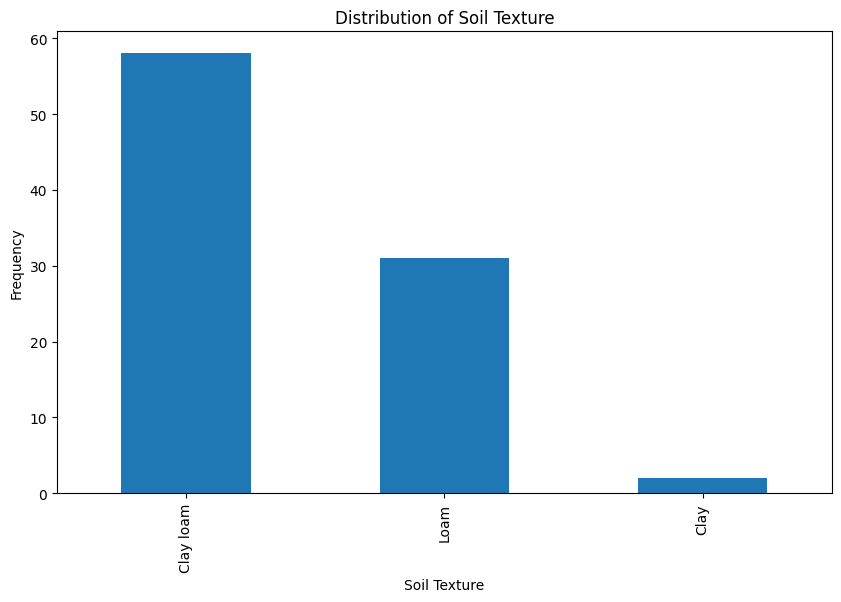

In [387]:
for cols in categorical_columns:
    plt.figure(figsize=(10,6))
    
    df[cols].value_counts().plot(kind='bar')
    
    plt.title(f"Distribution of {cols}")
    plt.xlabel(cols)
    plt.ylabel("Frequency")
    plt.show()

In [388]:
df["District"] = df["District"].replace({ "Barisal": "Barishal"})

In [389]:
df["District"].value_counts()

District
Jhalokathi            50
Rangamati             19
Bhola                  7
Meghnar Paschimati     7
Barishal               4
Nilkamal               4
Name: count, dtype: int64

Analyze the relationship between Nitrogen and categorical columns(District, Land Class, Soil Texture)

Category-wise N Distribution

In [390]:
for col in categorical_columns:
    print(f"\nRelationship between {col} and {TARGET}")
    print(df.groupby(col)[TARGET].agg(["mean", "median", "std"]))


Relationship between District and Available Phosphorus (µg/g soil)
                        mean  median       std
District                                      
Barishal            3.040000   2.510  1.671606
Bhola               4.338571   4.160  2.331991
Jhalokathi          3.109600   2.695  1.269588
Meghnar Paschimati  9.720000   9.700  1.410059
Nilkamal            3.787500   3.610  1.079672
Rangamati           2.861579   2.620  1.055327

Relationship between Land Class and Available Phosphorus (µg/g soil)
                      mean  median       std
Land Class                                  
Medium high land  3.282824    2.71  1.637186
Medium low land   9.421667    9.41  1.279960

Relationship between Soil Texture and Available Phosphorus (µg/g soil)
                  mean  median       std
Soil Texture                            
Clay          2.020000    2.02  0.494975
Clay loam     3.217069    2.71  1.440324
Loam          4.675484    3.96  3.040819


Interpretation of ANOVA

ANOVA means Analysis of Variance.

It is a statistical test used to check whether the average value of a numerical column is significantly different across multiple categories/groups.

Example:

Does average Total Nitrogen (%) differ across Districts?

ANOVA tells:

p-value < 0.05  → group averages are significantly different
p-value >= 0.05 → no strong evidence of difference

In simple words: ANOVA checks whether categories have meaningfully different average values.

In [391]:
from scipy.stats import f_oneway

for col in categorical_columns:
    print(f"\nANOVA for {col} and {TARGET}")
    groups = [group[TARGET] for name, group in df.groupby(col)]
    f_stat, p_value = f_oneway(*groups)

    print("F-statistic:", f_stat)
    print("p-value:", p_value)


ANOVA for District and Available Phosphorus (µg/g soil)
F-statistic: 31.61056550154474
p-value: 4.715401312791536e-18

ANOVA for Land Class and Available Phosphorus (µg/g soil)
F-statistic: 80.55577921103146
p-value: 4.2262263485334344e-14

ANOVA for Soil Texture and Available Phosphorus (µg/g soil)
F-statistic: 5.407747051496825
p-value: 0.006094464133541021


Boxplot Observation

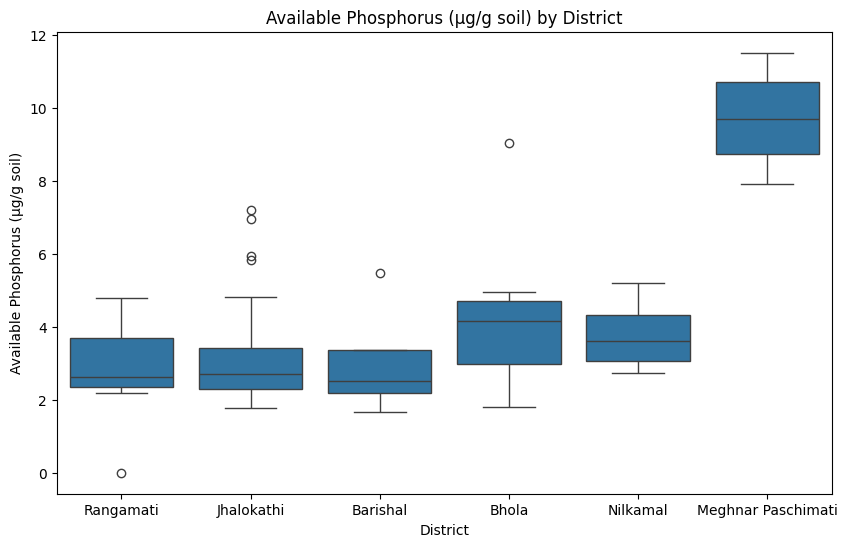

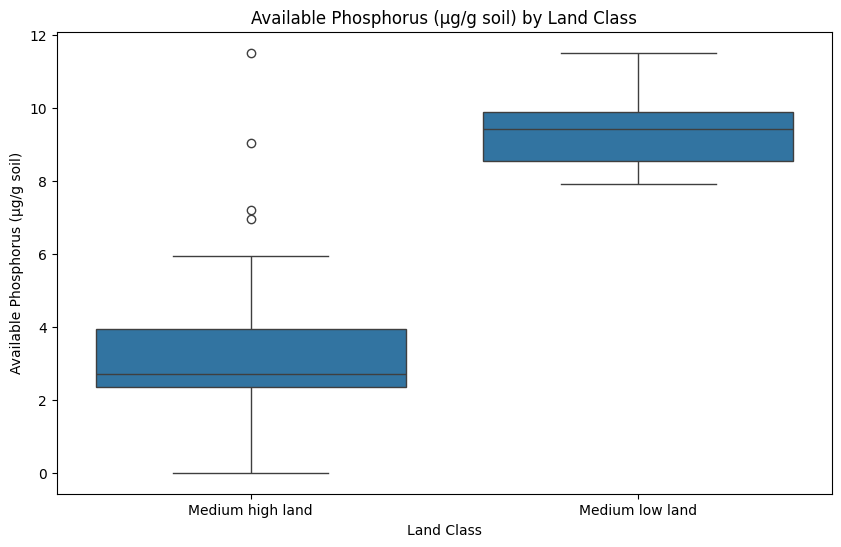

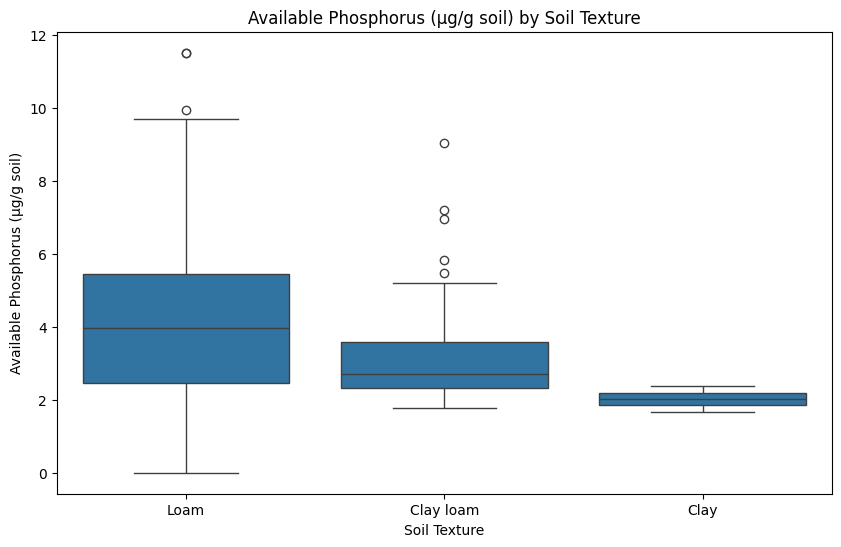

In [392]:
for col in categorical_columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=col, y=TARGET, data=df)
    plt.title(f"{TARGET} by {col}")
    plt.show()

In [393]:
from scipy.stats import pearsonr
for col in numeric_columns:
    corr, p_value = pearsonr(df[col], df[TARGET])
    
    print(f"\n{col}")
    print("Pearson correlation:", corr)
    print("p-value:", p_value)


Reaction (pH)
Pearson correlation: 0.4785250347602752
p-value: 1.6053168559093567e-06

Salinity (EC, dS/m)
Pearson correlation: -0.16885415146638527
p-value: 0.10959624892722562

Organic Matter (%)
Pearson correlation: nan
p-value: nan

Total Nitrogen (%)
Pearson correlation: -0.1507989600891696
p-value: 0.15363242085929338

Potassium (meq/100 g soil)
Pearson correlation: -0.19656604273061742
p-value: 0.06183704637053122

Sulfur (µg/g soil)
Pearson correlation: -0.10019948606121919
p-value: 0.34465390175311006

Calcium (meq/100 g soil)
Pearson correlation: 0.5540914925969659
p-value: 1.2145096992785448e-08

Magnesium (µg/g soil)
Pearson correlation: -0.46190881479268253
p-value: 4.0493501581622724e-06


corr near +1  = strong positive linear relation
corr near -1  = strong negative linear relation
corr near 0   = weak/no linear relation

In [394]:
feature_columns = numeric_columns + categorical_columns

X = df[feature_columns].copy()
y = df[TARGET].copy()

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (91, 11)
Target (y) shape: (91,)


In [395]:
print(X.columns)

Index(['Reaction (pH)', 'Salinity (EC, dS/m)', 'Organic Matter (%)',
       'Total Nitrogen (%)', 'Potassium (meq/100 g soil)',
       'Sulfur (µg/g soil)', 'Calcium (meq/100 g soil)',
       'Magnesium (µg/g soil)', 'District', 'Land Class', 'Soil Texture'],
      dtype='object')


Train Test Split

In [396]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Training target shape:", y_train.shape) 
print("Testing features shape:", X_test.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (72, 11)
Training target shape: (72,)
Testing features shape: (19, 11)
Testing target shape: (19,)


Create Preprocessing Pipeline

In [397]:
# numeric_transformer = Pipeline(steps=[
#         ("imputer", SimpleImputer(strategy='median')),
#         ("scaler", StandardScaler())
# ])

# categorical_transformer = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy='most_frequent')),
#     ("onehot", OneHotEncoder(handle_unknown='ignore'))
# ])

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", numeric_transformer, numeric_columns),
#         ("cat", categorical_transformer, categorical_columns)
#     ]
# )

In [398]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

In [399]:
MLFLOW_TRACKING_URI = r"file:../mlruns"
EXPERIMENT_NAME = "p_prediction_experiment_selected_feat_multiple_models_remove_outliers"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

2026/05/20 16:02:26 INFO mlflow.tracking.fluent: Experiment with name 'p_prediction_experiment_selected_feat_multiple_models_remove_outliers' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:d:/project/n-prediction-mlflow/train/../mlruns/847961615087137194', creation_time=1779271346093, experiment_id='847961615087137194', last_update_time=1779271346093, lifecycle_stage='active', name='p_prediction_experiment_selected_feat_multiple_models_remove_outliers', tags={}, trace_location=None, workspace='default'>

In [400]:
models_and_params = {
    "RandomForest": {
        "model": RandomForestRegressor(),
        "params": {
            "regressor__n_estimators": [100],
            "regressor__max_depth": [10,20,30]
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingRegressor(),
        "params": {
            "regressor__n_estimators": [100],
            "regressor__max_depth": [3,5,7]
        }
    },
    "SVR": {
        "model": SVR(),
        "params": {
            "regressor__kernel": ["rbf", "linear"],
            "regressor__C": [1, 10]
        },
    },
}

In [401]:
MIN_NUM_FEATURES = 3
MAX_NUM_FEATURES = 3

STATIC_NUMERIC_FEATURES = ["Reaction (pH)", "Salinity (EC, dS/m)"]
TOTAL_NUMERIC_FEATURES = 3

print(f"Minimum number of features: {MIN_NUM_FEATURES}")
print(f"Maximum number of features: {MAX_NUM_FEATURES}")
print(f"Static numeric features: {STATIC_NUMERIC_FEATURES}")

Minimum number of features: 3
Maximum number of features: 3
Static numeric features: ['Reaction (pH)', 'Salinity (EC, dS/m)']


In [402]:
def powerset(iterable):
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(MIN_NUM_FEATURES, MAX_NUM_FEATURES + 1))

In [403]:
def powerset_with_static(numeric_columns):
    # print("numeric_columns:")
    # print(numeric_columns)

    # print("\nSTATIC_NUMERIC_FEATURES:")
    # print(STATIC_NUMERIC_FEATURES)

    remaining_numeric_columns = [
        col for col in numeric_columns
        if col not in STATIC_NUMERIC_FEATURES
    ]

    # print("\nremaining_numeric_columns:")
    # print(remaining_numeric_columns)

    # print("\nTotal numeric columns:", len(numeric_columns))
    # print("Total static columns:", len(STATIC_NUMERIC_FEATURES))
    # print("Total remaining columns:", len(remaining_numeric_columns))

    number_of_dynamic_features = TOTAL_NUMERIC_FEATURES - len(STATIC_NUMERIC_FEATURES)

    # print("\nTOTAL_NUMERIC_FEATURES:", TOTAL_NUMERIC_FEATURES)
    # print("number_of_dynamic_features:", number_of_dynamic_features)

    return (
        STATIC_NUMERIC_FEATURES + list(combo)
        for combo in combinations(remaining_numeric_columns, number_of_dynamic_features)
    )

In [404]:
feature_combinations = list(powerset_with_static(numeric_columns))

print("Total combinations:", len(feature_combinations))

for i, combo in enumerate(feature_combinations, start=1):
    print(f"{i}. {combo} | Total features: {len(combo)}")

Total combinations: 6
1. ['Reaction (pH)', 'Salinity (EC, dS/m)', 'Organic Matter (%)'] | Total features: 3
2. ['Reaction (pH)', 'Salinity (EC, dS/m)', 'Total Nitrogen (%)'] | Total features: 3
3. ['Reaction (pH)', 'Salinity (EC, dS/m)', 'Potassium (meq/100 g soil)'] | Total features: 3
4. ['Reaction (pH)', 'Salinity (EC, dS/m)', 'Sulfur (µg/g soil)'] | Total features: 3
5. ['Reaction (pH)', 'Salinity (EC, dS/m)', 'Calcium (meq/100 g soil)'] | Total features: 3
6. ['Reaction (pH)', 'Salinity (EC, dS/m)', 'Magnesium (µg/g soil)'] | Total features: 3


In [405]:
best_r2_score = float('-inf')
best_pipeline = None
best_info = None

In [406]:
results = []

# for numeric_columns in powerset_with_static(numeric_columns):

selected_numeric_columns = list(numeric_columns)
combo_name = "_".join([col.split()[0] for col in selected_numeric_columns])

print(f"\n{'='*70}")
print(f"Feature Combination: {selected_numeric_columns} ({len(selected_numeric_columns)} numeric features)")
print(f"Combo Name: {combo_name}")
print(f"{'='*70}")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("onehot", OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
transformers=[
        ("num", numeric_transformer, selected_numeric_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

for model_name, config in models_and_params.items():
    model = config["model"]
    param_grid = list(ParameterGrid(config["params"]))
    
    print(f"→ Training {model_name} | Total hyperparameter runs: {len(param_grid)}")
    
    for run_number, params in enumerate(param_grid, start=1):
        with mlflow.start_run(run_name=f"{model_name}_{combo_name}_run_{run_number}"):
            pipeline = Pipeline(steps=[
                ("preprocessor", preprocessor),
                ("regressor", model)
            ])
            pipeline.set_params(**params)
            pipeline.fit(X_train, y_train)
            y_train_pred = pipeline.predict(X_train)
            y_test_pred = pipeline.predict(X_test)
            
            train_metrics = evaluate_model(y_train, y_train_pred)
            test_metrics = evaluate_model(y_test, y_test_pred)
            
            current_test_r2 = test_metrics["R2 Score"]
            if current_test_r2 > best_r2_score:
                best_r2_score = current_test_r2
                best_pipeline  =pipeline
                best_info = {
                        "model_name": model_name,
                        "combo_name": combo_name,
                        "test_r2": current_test_r2,
                        "params": params,
                        "num_features": len(selected_numeric_columns)
                    }
            
            mlflow.log_param("model_name", model_name)
            mlflow.log_param("feature_combo", combo_name)
            mlflow.log_param("selected_numeric_features", selected_numeric_columns)
            mlflow.log_param("num_numeric_features", len(selected_numeric_columns))
            mlflow.log_param("total_features", len(selected_numeric_columns) + len(categorical_columns))
            mlflow.log_param("target", TARGET)
            
            for param_name, param_value in params.items():
                clean_param_name = param_name.replace("regressor__", "")
                mlflow.log_param(clean_param_name, param_value)
            
            mlflow.log_metric("train_MAE", train_metrics["MAE"])
            mlflow.log_metric("train_MSE", train_metrics["MSE"])
            mlflow.log_metric("train_RMSE", train_metrics["RMSE"])
            mlflow.log_metric("train_R2", train_metrics["R2 Score"])

            mlflow.log_metric("test_MAE", test_metrics["MAE"])
            mlflow.log_metric("test_MSE", test_metrics["MSE"])
            mlflow.log_metric("test_RMSE", test_metrics["RMSE"])
            mlflow.log_metric("test_R2", test_metrics["R2 Score"])
            
            mlflow.sklearn.log_model(pipeline, artifact_path="model")
            
            result_row = {
                "model_name": model_name,
                "combo_name": combo_name,
                "num_features": len(selected_numeric_columns),
                "features_used": selected_numeric_columns,
                "params": params,
                "train_metrics": train_metrics,
                "test_metrics": test_metrics
            }
            
            results.append(result_row)
            
            print(
                f"{model_name} run {run_number} | "
                f"Test RMSE: {test_metrics['RMSE']:.4f} | "
                f"Test R2: {test_metrics['R2 Score']:.4f}"
            )
            
print("\n" + "="*80)
print("TRAINING COMPLETED")
print(f"Best Model: {best_info['model_name']} | Combo: {best_info['combo_name']}")
print(f"Test R2: {best_info['test_r2']:.4f}")
print("="*80)


Feature Combination: ['Reaction (pH)', 'Salinity (EC, dS/m)', 'Organic Matter (%)', 'Total Nitrogen (%)', 'Potassium (meq/100 g soil)', 'Sulfur (µg/g soil)', 'Calcium (meq/100 g soil)', 'Magnesium (µg/g soil)'] (8 numeric features)
Combo Name: Reaction_Salinity_Organic_Total_Potassium_Sulfur_Calcium_Magnesium
→ Training RandomForest | Total hyperparameter runs: 3


2026/05/20 16:02:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/20 16:02:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest run 1 | Test RMSE: 1.1061 | Test R2: 0.7923


2026/05/20 16:02:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/20 16:02:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest run 2 | Test RMSE: 1.1374 | Test R2: 0.7803


...

SVR run 2 | Test RMSE: 2.7636 | Test R2: -0.2969


2026/05/20 16:02:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/20 16:02:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SVR run 3 | Test RMSE: 1.1964 | Test R2: 0.7570


2026/05/20 16:03:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/20 16:03:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SVR run 4 | Test RMSE: 10.3981 | Test R2: -17.3590

TRAINING COMPLETED
Best Model: GradientBoosting | Combo: Reaction_Salinity_Organic_Total_Potassium_Sulfur_Calcium_Magnesium
Test R2: 0.8084


In [408]:
save_path = "../models/p_prediction_model.pkl"
joblib.dump(best_pipeline, save_path)

['../models/p_prediction_model.pkl']

In [409]:
best_info

{'model_name': 'GradientBoosting',
 'combo_name': 'Reaction_Salinity_Organic_Total_Potassium_Sulfur_Calcium_Magnesium',
 'test_r2': 0.8084375601318348,
 'params': {'regressor__max_depth': 7, 'regressor__n_estimators': 100},
 'num_features': 8}